## Dự đoán Aggregate Rating nhà hàng theo mô hình XGBoost

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from xgboost import XGBClassifier, XGBRegressor

REVIEW DATASET SAU KHI ĐÃ XỬ LÍ

In [31]:
df = pd.read_csv('../data/processed/clean_ds_train_data.csv')
df_model = df.copy()

# Tạo nhãn khoảng
bins = [0, 3.0, 4.0, 5.0]
labels = [0, 1, 2]
label_names = ['Thấp (< 3.0)', 'Trung bình (3.0–4.0)', 'Tốt (≥ 4.0)']

rating_class = pd.cut(df_model['Aggregate rating'], bins=bins, labels=labels, include_lowest=True).astype(int)

print('Aggregate rating phân bố theo các khoảng:')
counts = rating_class.value_counts().sort_index()
for i, cnt in counts.items():
    print(f'  Khoảng {i} ({label_names[i]}): {cnt} mẫu ({cnt/len(rating_class)*100:.1f}%)')

Aggregate rating phân bố theo các khoảng:
  Khoảng 0 (Thấp (< 3.0)): 1901 mẫu (25.7%)
  Khoảng 1 (Trung bình (3.0–4.0)): 4388 mẫu (59.3%)
  Khoảng 2 (Tốt (≥ 4.0)): 1114 mẫu (15.0%)


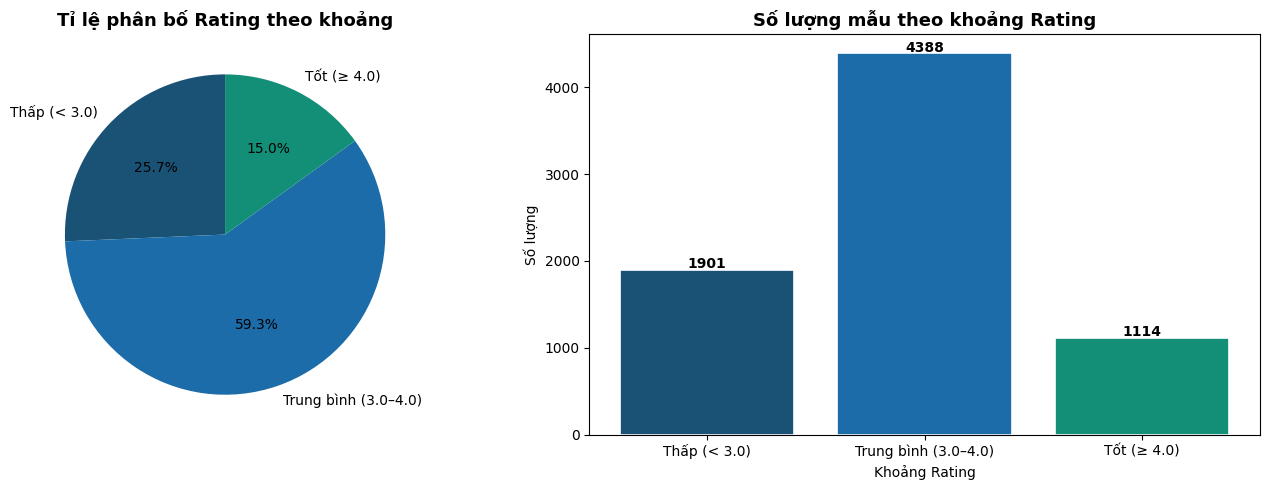

In [32]:
# Visualize 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1a5276', '#1b6ca8', '#148f77']
counts_vals = [counts[i] for i in range(3)]  

axes[0].pie(counts_vals, labels=label_names, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Tỉ lệ phân bố Rating theo khoảng', fontsize=13, fontweight='bold')

bars = axes[1].bar(label_names, counts_vals, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Số lượng mẫu theo khoảng Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Khoảng Rating')
axes[1].set_ylabel('Số lượng')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

CHỌN ĐẶC TRƯNG CẦN DÙNG VÀ TÁCH DATASET

In [33]:
target = 'Aggregate rating' 
features = [col for col in df_model.columns if col != target]

X = df_model[features]
y_c = rating_class
y_r = df_model['Aggregate rating']

print(f'Số features: {len(features)}')
print(f'Số samples: {len(X)}')

Số features: 10
Số samples: 7403


In [34]:
X_train_c, X_valid_c, y_train_c, y_valid_c = train_test_split(
    X, y_c,
    test_size=0.2,
    random_state=42,
    stratify=y_c  
)

print(f'Train set: {X_train_c.shape[0]} mẫu')
print(f'Valid set: {X_valid_c.shape[0]} mẫu')

Train set: 5922 mẫu
Valid set: 1481 mẫu


In [35]:
X_train_r, X_valid_r, y_train_r, y_valid_r = train_test_split(
    X, y_r,
    test_size=0.2,
    random_state=42
)

print(f'Train set: {X_train_r.shape[0]} mẫu')
print(f'Valid set: {X_valid_r.shape[0]} mẫu')

Train set: 5922 mẫu
Valid set: 1481 mẫu


HUẤN LUYỆN MÔ HÌNH XGBOOST CLASSIFIER

In [36]:
class_counts = y_train_c.value_counts().sort_index()
total = len(y_train_c)
scale_pos = total / (len(class_counts) * class_counts)
sample_weights_c = y_train_c.map(scale_pos)

xgb_model_c = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_model_c.fit(X_train_c, y_train_c, sample_weight=sample_weights_c)
print('Huấn luyện mô hình XGBoost classifier hoàn tất!')

Huấn luyện mô hình XGBoost classifier hoàn tất!


ĐÁNH GIÁ MÔ HÌNH XGBOOST CLASSIFIER

In [37]:
y_pred_c = xgb_model_c.predict(X_valid_c)

acc = accuracy_score(y_valid_c, y_pred_c)
f1_macro = f1_score(y_valid_c, y_pred_c, average='macro')
f1_weighted = f1_score(y_valid_c, y_pred_c, average='weighted')

print(f'Accuracy       : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 (macro)     : {f1_macro:.4f}')
print(f'F1 (weighted)  : {f1_weighted:.4f}')

print()
print('Classification Report:')
print(classification_report(
    y_valid_c, 
    y_pred_c, 
    target_names=['Thấp', 'Trung bình', 'Tốt'] 
))

Accuracy       : 0.6853 (68.53%)
F1 (macro)     : 0.6765
F1 (weighted)  : 0.6887

Classification Report:
              precision    recall  f1-score   support

        Thấp       0.56      0.74      0.64       380
  Trung bình       0.79      0.65      0.71       878
         Tốt       0.63      0.73      0.67       223

    accuracy                           0.69      1481
   macro avg       0.66      0.71      0.68      1481
weighted avg       0.71      0.69      0.69      1481



In [38]:
# Đánh giá theo Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model_c, X, y_c, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'Cross-Validation (5-fold) F1 macro:')
print(f'Scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')

Cross-Validation (5-fold) F1 macro:
Scores: [np.float64(0.6549), np.float64(0.6697), np.float64(0.6458), np.float64(0.6523), np.float64(0.668)]
Mean  : 0.6581
Std   : 0.0093


CONFUSION MATRIX XGBOOST CLASSIFIER

In [39]:
cm = confusion_matrix(y_valid_c, y_pred_c)

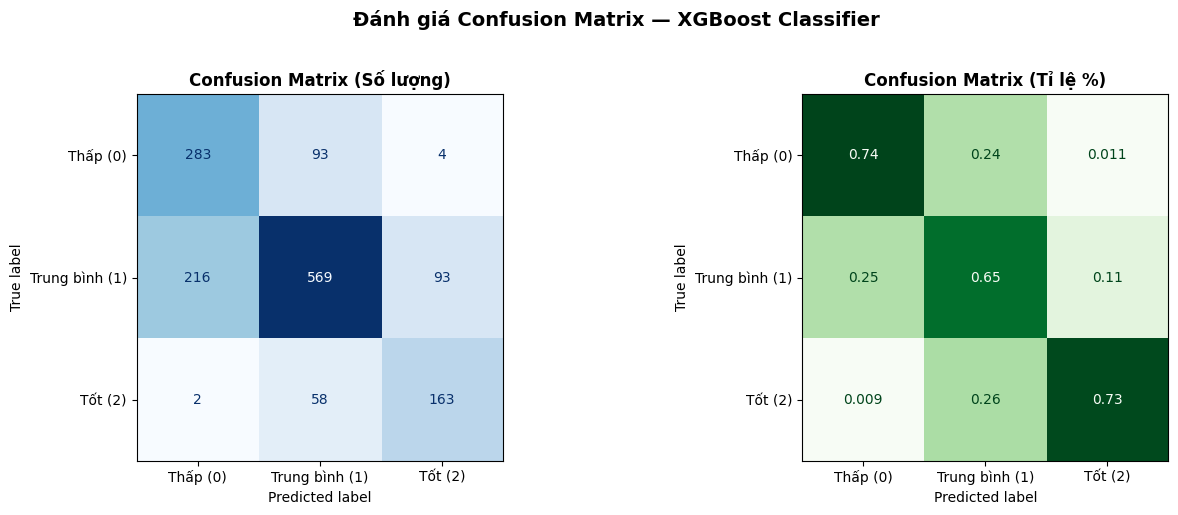

In [40]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Tốt (2)'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Số lượng)', fontweight='bold')

cm_norm = confusion_matrix(y_valid_c, y_pred_c, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Tốt (2)'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Tỉ lệ %)', fontweight='bold')

plt.suptitle('Đánh giá Confusion Matrix — XGBoost Classifier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

HUẤN LUYỆN MÔ HÌNH XGBOOST REGRESSOR

In [41]:
xgb_model_r = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model_r.fit(X_train_r, y_train_r)
print('Huấn luyện XGBoost regressor hoàn tất!')

Huấn luyện XGBoost regressor hoàn tất!


ĐÁNH GIÁ MÔ HÌNH XGBOOST REGRESSOR

In [42]:
y_pred_r = xgb_model_r.predict(X_valid_r)

mae = mean_absolute_error(y_valid_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_valid_r, y_pred_r))
r2 = r2_score(y_valid_r, y_pred_r)

print(f'Mean Abs Error (MAE)  : {mae:.4f}')
print(f'Root Mean Sq E (RMSE) : {rmse:.4f}')
print(f'R-squared      (R²)   : {r2:.4f}')
print(f'\nÝ nghĩa: Trung bình dự đoán sai lệch ±{mae:.3f} điểm so với thực tế')

Mean Abs Error (MAE)  : 0.2459
Root Mean Sq E (RMSE) : 0.3280
R-squared      (R²)   : 0.6521

Ý nghĩa: Trung bình dự đoán sai lệch ±0.246 điểm so với thực tế


In [43]:
# Đánh giá theo Cross-validation
cv_r = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_r_mae = cross_val_score(xgb_model_r, X, y_r, cv=cv_r, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_scores_r_r2 = cross_val_score(xgb_model_r, X, y_r, cv=cv_r, scoring='r2', n_jobs=-1)

print('Cross-Validation (5-fold) — Regressor:')
print(f'MAE Scores  : {[round(-s, 4) for s in cv_scores_r_mae]}')
print(f'MAE Mean    : {-cv_scores_r_mae.mean():.4f} ± {cv_scores_r_mae.std():.4f}')
print(f'R² Scores   : {[round(s, 4) for s in cv_scores_r_r2]}')
print(f'R² Mean     : {cv_scores_r_r2.mean():.4f} ± {cv_scores_r_r2.std():.4f}')

Cross-Validation (5-fold) — Regressor:
MAE Scores  : [np.float64(0.2464), np.float64(0.2699), np.float64(0.2488), np.float64(0.2502), np.float64(0.2544)]
MAE Mean    : 0.2539 ± 0.0084
R² Scores   : [np.float64(0.6475), np.float64(0.5691), np.float64(0.609), np.float64(0.6167), np.float64(0.6145)]
R² Mean     : 0.6113 ± 0.0250


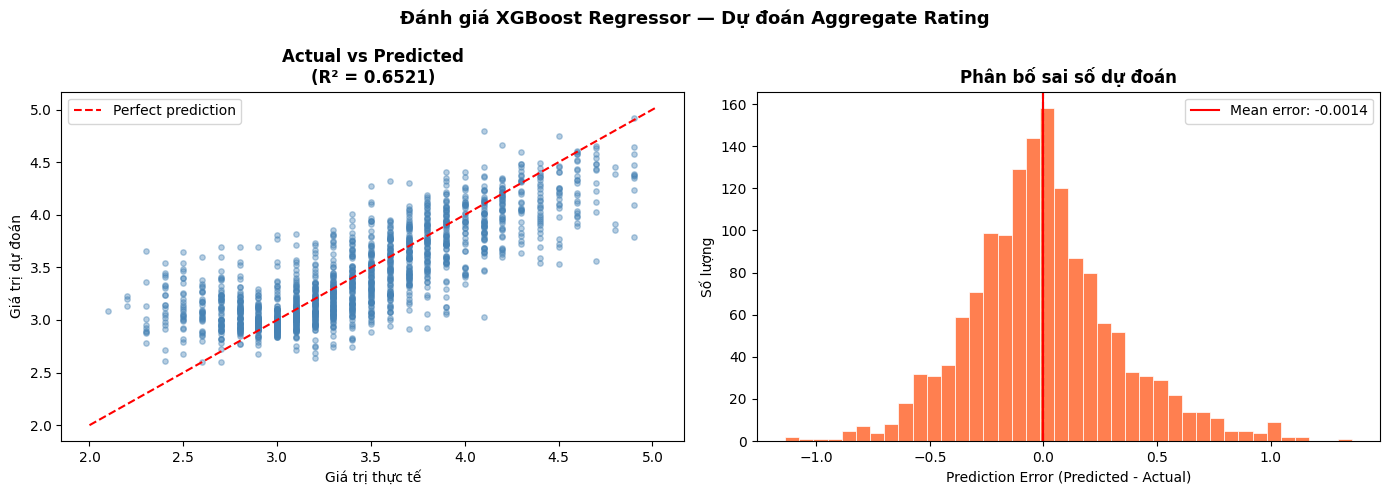

In [44]:
# Visualize: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_valid_r, y_pred_r, alpha=0.4, color='steelblue', s=15)
lims = [min(y_valid_r.min(), y_pred_r.min()) - 0.1,
        max(y_valid_r.max(), y_pred_r.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Giá trị thực tế')
axes[0].set_ylabel('Giá trị dự đoán')
axes[0].set_title(f'Actual vs Predicted\n(R² = {r2:.4f})', fontweight='bold')
axes[0].legend()

errors = y_pred_r - y_valid_r.values
axes[1].hist(errors, bins=40, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(errors.mean(), color='red', linestyle='-', linewidth=1.5, label=f'Mean error: {errors.mean():.4f}')
axes[1].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân bố sai số dự đoán', fontweight='bold')
axes[1].legend()

plt.suptitle('Đánh giá XGBoost Regressor — Dự đoán Aggregate Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE CỦA CLASSIFIER VÀ REGRESSOR

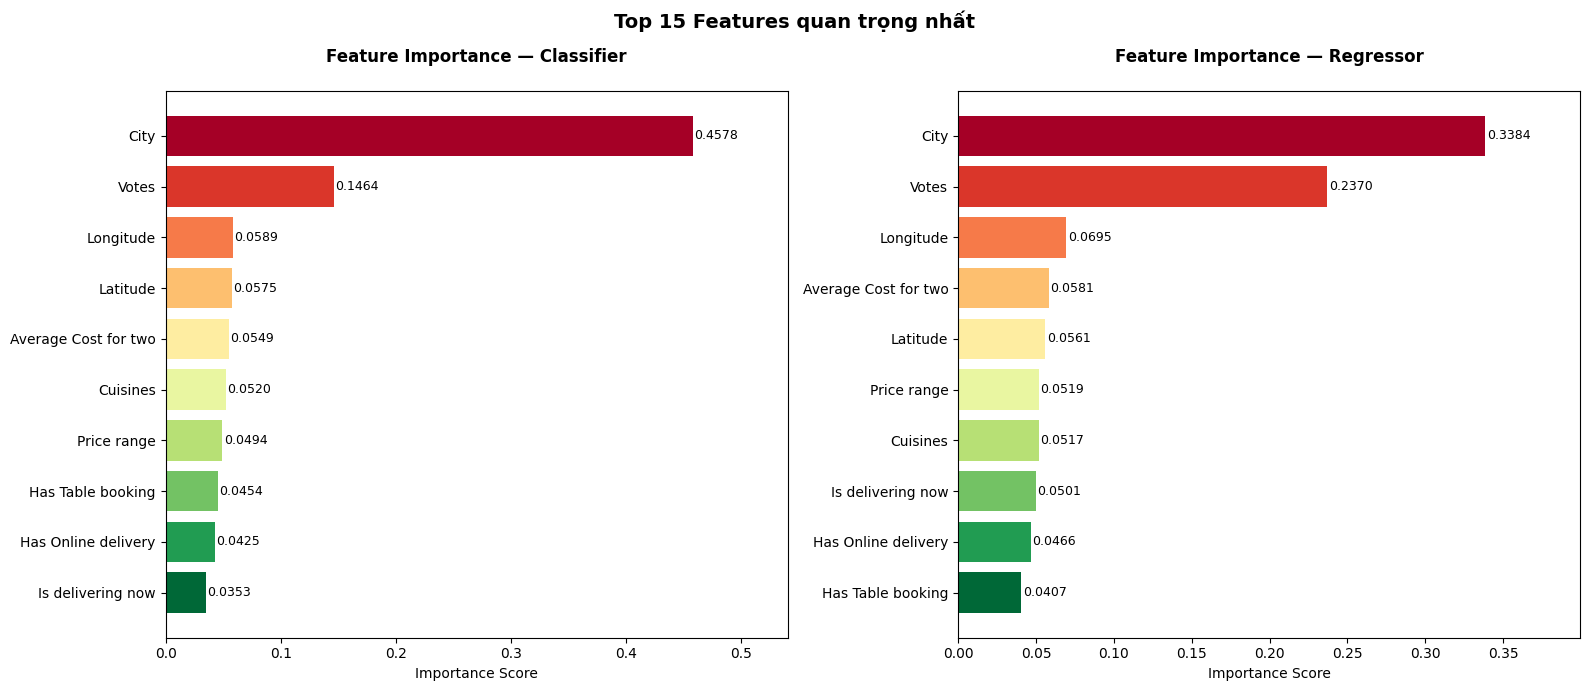

In [45]:
def plot_feature_importance(model, features, title, ax, top_n=15):
    importances = model.feature_importances_
    feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})\
                .sort_values('Importance', ascending=False).head(top_n)
    
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0, 1, len(feat_df)))
    bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color=colors_bar)
    
    for bar, val in zip(bars, feat_df['Importance'][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    ax.set_xlabel('Importance Score')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, feat_df['Importance'].max() * 1.18)
    return feat_df

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feat_clf = plot_feature_importance(xgb_model_c, features, 'Feature Importance — Classifier\n', axes[0])
feat_reg = plot_feature_importance(xgb_model_r, features, 'Feature Importance — Regressor\n', axes[1])

plt.suptitle('Top 15 Features quan trọng nhất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()